# 🔫 Studi Kasus 2: Unsupervised Learning
# Segmentasi & Pengelompokan Senjata Valorant Berdasarkan Performa

---

## 📌 Latar Belakang

Dalam game **Valorant**, pemilihan senjata merupakan keputusan strategis yang sangat krusial. Setiap senjata memiliki karakteristik unik seperti harga, kecepatan tembak, kapasitas amunisi, dan kemampuan damage di berbagai jarak. Pemain profesional memilih senjata berdasarkan peran dan situasi round (eco round, half-buy, full-buy).

Dengan menggunakan **Unsupervised Learning (K-Means Clustering)**, kita dapat mengelompokkan senjata-senjata di Valorant ke dalam cluster berdasarkan statistik performa mereka, dan menemukan kelompok/archetype senjata yang bermakna dari data — tanpa label manual.

---

## 📊 Sumber Dataset

| Detail | Keterangan |
|--------|------------|
| **Nama Dataset** | Valorant Weapons Statistics |
| **Sumber** | [Kaggle – Valorant Weapons Dataset](https://www.kaggle.com/datasets/aarishmughal/valorant-weapons-stats-latest) |
| **File Utama** | `valorant_weapons.csv` |
| **Jumlah Senjata** | 20 senjata |

> **Catatan:** Dataset ini **berbeda** dari Studi Kasus 1 yang menggunakan data pertandingan VCT Champions 2025. Dataset ini berfokus pada spesifikasi teknis dan statistik performa setiap senjata di dalam game.

---

## 🔬 Objektif

- **Tujuan**: Mengelompokkan senjata Valorant ke dalam cluster berdasarkan profil performa (damage, harga, fire rate, kapasitas ammo).
- **Fitur yang digunakan**: Price, FireRate, Ammo, ReserveAmmo, serta nilai damage head/body/legs di berbagai jarak.
- **Algoritma**: K-Means Clustering + PCA untuk visualisasi 2D.
- **Harapan Cluster**: Budget Eco Weapon | Mid-Range Aggressive | Premium High-Damage / Sniper

---

## 📦 Tahap 1: Import Library

In [43]:
import warnings
warnings.filterwarnings('ignore')

# ─── Data Manipulation ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisasi ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ─── Preprocessing ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

# ─── Clustering ─────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans

# ─── Evaluasi ───────────────────────────────────────────────────────────────
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ─── Utilitas ───────────────────────────────────────────────────────────────
import joblib, os

# ─── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

# Palet warna bertema Valorant
VALORANT_RED   = '#FF4655'
VALORANT_CYAN  = '#00B4D8'
VALORANT_DARK  = '#0F1923'
CLUSTER_COLORS = ['#F72585', '#4CC9F0', '#2DC653', '#FF9F1C']

print('✅ Semua library berhasil diimpor!')

✅ Semua library berhasil diimpor!


---
## 📂 Tahap 2: Load & Eksplorasi Dataset

In [44]:
# ─── Load Dataset Senjata ────────────────────────────────────────────────────
DATA_PATH = os.path.join('data', 'weapons', 'valorant_weapons.csv')
df_raw    = pd.read_csv(DATA_PATH)

print('📄 valorant_weapons.csv shape:', df_raw.shape)
print('\nKolom tersedia:')
print(df_raw.columns.tolist())
df_raw.head()

📄 valorant_weapons.csv shape: (24, 58)

Kolom tersedia:
['Name', 'Class', 'Price', 'Damage_Head_0-30m', 'Damage_Head_30-50m', 'Damage_Body_0-30m', 'Damage_Body_30-50m', 'Damage_Legs_0-30m', 'Damage_Legs_30-50m', 'Penetration', 'Ammo', 'ReserveAmmo', 'Mode', 'FireRate', 'AltFireRate', 'Damage_Head_0-8m', 'Damage_Head_8-12m', 'Damage_Head_12-50m', 'Damage_Body_0-8m', 'Damage_Body_8-12m', 'Damage_Body_12-50m', 'Damage_Legs_0-8m', 'Damage_Legs_8-12m', 'Damage_Legs_12-50m', 'Damage_Head_0-50m', 'Damage_Body_0-50m', 'Damage_Legs_0-50m', 'Damage_Head_0-20m', 'Damage_Head_20-50m', 'Damage_Body_0-20m', 'Damage_Body_20-50m', 'Damage_Legs_0-20m', 'Damage_Legs_20-50m', 'Damage_Head_0-10m', 'Damage_Head_10-15m', 'Damage_Head_15-50m', 'Damage_Body_0-10m', 'Damage_Body_10-15m', 'Damage_Body_15-50m', 'Damage_Legs_0-10m', 'Damage_Legs_10-15m', 'Damage_Legs_15-50m', 'Damage_Head_30m+', 'Damage_Body_30m+', 'Damage_Legs_30m+', 'Damage_Head_0-7m', 'Damage_Head_7-15m', 'Damage_Body_0-7m', 'Damage_Body_7-15m

,Name,Class,Price,Damage_Head_0-30m,Damage_Head_30-50m,Damage_Body_0-30m,Damage_Body_30-50m,Damage_Legs_0-30m,Damage_Legs_30-50m,Penetration,...,Damage_Body_7-15m,Damage_Legs_0-7m,Damage_Legs_7-15m,Damage_Head_0-15m,Damage_Body_0-15m,Damage_Legs_0-15m,Damage_Front_primary,Damage_Front_secondary,Damage_Back_primary,Damage_Back_secondary
0,Ares,Heavy,1550,75.0,70.0,30.0,28.0,25.0,23.0,High,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bucky,Shotguns,850,NaN,NaN,NaN,NaN,NaN,NaN,Low,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Bulldog,Rifles,2050,NaN,NaN,NaN,NaN,NaN,NaN,Medium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Classic,Sidearm,0,78.0,66.0,26.0,22.0,22.0,18.0,Low,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Frenzy,Sidearm,450,NaN,NaN,NaN,NaN,NaN,NaN,Low,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# ─── Preview semua senjata dan kelas ─────────────────────────────────────────
print('=== DAFTAR SENJATA & KELAS ===')
print(df_raw[['Name', 'Class', 'Price']].dropna(subset=['Name']).to_string(index=False))

=== DAFTAR SENJATA & KELAS ===
             Name         Class  Price
             Ares         Heavy   1550
            Bucky      Shotguns    850
          Bulldog        Rifles   2050
          Classic       Sidearm      0
           Frenzy       Sidearm    450
            Ghost       Sidearm    500
       Golden Gun Miscellaneous      0
         Guardian        Rifles   2250
    Heavy Shields       Shields   1000
            Judge      Shotguns   1850
    Light Shields       Shields    400
          Marshal        Sniper    950
             Odin         Heavy   3200
         Operator        Sniper   4700
           Outlaw        Sniper   2400
          Phantom        Rifles   2900
    Regen Shields       Shields    650
          Sheriff       Sidearm    800
           Shorty       Sidearm    300
Snowball Launcher Miscellaneous      0
          Spectre          SMGs   1600
          Stinger          SMGs   1100
   Tactical Knife         Melee      0
           Vandal        Rifles  

In [46]:
# ─── Filter: Hapus Shields, Miscellaneous, Melee, dan baris kosong ───────────
EXCLUDE_CLASSES = ['Shields', 'Miscellaneous', 'Melee']
df = df_raw[~df_raw['Class'].isin(EXCLUDE_CLASSES)].copy()
df = df.dropna(subset=['Name', 'Class', 'Price']).reset_index(drop=True)

print(f'✅ Dataset setelah filter: {len(df)} senjata')
print(df[['Name', 'Class', 'Price', 'FireRate', 'Ammo']].to_string(index=False))

✅ Dataset setelah filter: 18 senjata
    Name    Class  Price  FireRate  Ammo
    Ares    Heavy   1550     10.00  50.0
   Bucky Shotguns    850      1.10   5.0
 Bulldog   Rifles   2050      9.50  24.0
 Classic  Sidearm      0      6.75  12.0
  Frenzy  Sidearm    450     10.00  15.0
   Ghost  Sidearm    500      6.75  13.0
Guardian   Rifles   2250      5.25  12.0
   Judge Shotguns   1850      3.50   5.0
 Marshal   Sniper    950      1.50   5.0
    Odin    Heavy   3200     12.00 100.0
Operator   Sniper   4700      0.60   5.0
  Outlaw   Sniper   2400      2.75   2.0
 Phantom   Rifles   2900     11.00  30.0
 Sheriff  Sidearm    800      4.00   6.0
  Shorty  Sidearm    300      3.33   2.0
 Spectre     SMGs   1600     13.33  30.0
 Stinger     SMGs   1100     16.00  20.0
  Vandal   Rifles   2900      9.75  25.0


In [47]:
# ─── Buat kolom fitur damage terbaik per senjata ─────────────────────────────
# Setiap senjata memiliki format damage yang berbeda-beda tergantung jenis
# Kita ambil nilai head damage & body damage yang paling representatif

def get_best_head_damage(row):
    """Ambil nilai head damage terbaik yang tersedia dari berbagai kolom jarak."""
    candidates = [
        row.get('Damage_Head_0-30m'), row.get('Damage_Head_0-50m'),
        row.get('Damage_Head_0-20m'), row.get('Damage_Head_0-15m'),
        row.get('Damage_Head_0-10m'), row.get('Damage_Head_0-8m'),
        row.get('Damage_Head_0-7m'),  row.get('Damage_Head_30m+'),
        row.get('Damage_Front_primary')
    ]
    valid = [c for c in candidates if pd.notna(c) and c > 0]
    return max(valid) if valid else np.nan

def get_best_body_damage(row):
    """Ambil nilai body damage terbaik yang tersedia dari berbagai kolom jarak."""
    candidates = [
        row.get('Damage_Body_0-30m'), row.get('Damage_Body_0-50m'),
        row.get('Damage_Body_0-20m'), row.get('Damage_Body_0-15m'),
        row.get('Damage_Body_0-10m'), row.get('Damage_Body_0-8m'),
        row.get('Damage_Body_0-7m'),  row.get('Damage_Body_30m+'),
        row.get('Damage_Front_secondary')
    ]
    valid = [c for c in candidates if pd.notna(c) and c > 0]
    return max(valid) if valid else np.nan

def get_best_legs_damage(row):
    """Ambil nilai leg damage terbaik."""
    candidates = [
        row.get('Damage_Legs_0-30m'), row.get('Damage_Legs_0-50m'),
        row.get('Damage_Legs_0-20m'), row.get('Damage_Legs_0-15m'),
        row.get('Damage_Legs_0-10m'), row.get('Damage_Legs_0-8m'),
        row.get('Damage_Legs_0-7m'),  row.get('Damage_Legs_30m+'),
        row.get('Damage_Back_secondary')
    ]
    valid = [c for c in candidates if pd.notna(c) and c > 0]
    return max(valid) if valid else np.nan

df['head_dmg_max'] = df.apply(get_best_head_damage, axis=1)
df['body_dmg_max'] = df.apply(get_best_body_damage, axis=1)
df['legs_dmg_max'] = df.apply(get_best_legs_damage, axis=1)

# Penetration encoding: Low=1, Medium=2, High=3
penet_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['penetration_enc'] = df['Penetration'].map(penet_map).fillna(1)

print('✅ Fitur damage terbaik berhasil diekstrak!')
df[['Name', 'Class', 'Price', 'FireRate', 'Ammo', 'head_dmg_max', 'body_dmg_max', 'legs_dmg_max', 'penetration_enc']].to_string(index=False)

✅ Fitur damage terbaik berhasil diekstrak!


'    Name    Class  Price  FireRate  Ammo  head_dmg_max  body_dmg_max  legs_dmg_max  penetration_enc\n    Ares    Heavy   1550     10.00  50.0          75.0          30.0          25.0                3\n   Bucky Shotguns    850      1.10   5.0          40.0          20.0          17.0                1\n Bulldog   Rifles   2050      9.50  24.0         115.0          35.0          29.0                2\n Classic  Sidearm      0      6.75  12.0          78.0          26.0          22.0                1\n  Frenzy  Sidearm    450     10.00  15.0          78.0          26.0          22.0                1\n   Ghost  Sidearm    500      6.75  13.0         105.0          30.0          25.0                2\nGuardian   Rifles   2250      5.25  12.0         195.0          65.0          49.0                3\n   Judge Shotguns   1850      3.50   5.0          34.0          17.0          14.0                2\n Marshal   Sniper    950      1.50   5.0         202.0         101.0          85.0        

In [48]:
# ─── Tampilkan tabel fitur lengkap ───────────────────────────────────────────
print('=== TABEL FITUR SENJATA (SEBELUM CLUSTERING) ===')
df[['Name', 'Class', 'Price', 'FireRate', 'Ammo', 'ReserveAmmo',
    'head_dmg_max', 'body_dmg_max', 'legs_dmg_max', 'penetration_enc']]

=== TABEL FITUR SENJATA (SEBELUM CLUSTERING) ===


,Name,Class,Price,FireRate,Ammo,ReserveAmmo,head_dmg_max,body_dmg_max,legs_dmg_max,penetration_enc
0,Ares,Heavy,1550,10.00,50.0,100.0,75.0,30.0,25.0,3
1,Bucky,Shotguns,850,1.10,5.0,10.0,40.0,20.0,17.0,1
2,Bulldog,Rifles,2050,9.50,24.0,72.0,115.0,35.0,29.0,2
3,Classic,Sidearm,0,6.75,12.0,36.0,78.0,26.0,22.0,1
4,Frenzy,Sidearm,450,10.00,15.0,45.0,78.0,26.0,22.0,1
5,Ghost,Sidearm,500,6.75,13.0,39.0,105.0,30.0,25.0,2
6,Guardian,Rifles,2250,5.25,12.0,36.0,195.0,65.0,49.0,3
7,Judge,Shotguns,1850,3.50,5.0,15.0,34.0,17.0,14.0,2
8,Marshal,Sniper,950,1.50,5.0,15.0,202.0,101.0,85.0,2
9,Odin,Heavy,3200,12.00,100.0,200.0,95.0,38.0,32.0,3


---
## 🔍 Tahap 3: Exploratory Data Analysis (EDA)

In [49]:
# ─── Statistik Deskriptif ─────────────────────────────────────────────────────
FEAT_COLS = ['Price', 'FireRate', 'Ammo', 'ReserveAmmo',
             'head_dmg_max', 'body_dmg_max', 'legs_dmg_max', 'penetration_enc']

print('=== STATISTIK DESKRIPTIF FITUR SENJATA ===')
df[FEAT_COLS].describe().round(2)

=== STATISTIK DESKRIPTIF FITUR SENJATA ===


,Price,FireRate,Ammo,ReserveAmmo,head_dmg_max,body_dmg_max,legs_dmg_max,penetration_enc
count,18.00,18.00,18.00,18.00,18.00,18.00,18.00,18.00
mean,1686.11,7.06,20.06,51.83,119.67,48.72,39.83,2.06
std,1222.44,4.57,23.62,48.35,69.84,40.59,32.14,0.80
min,0.00,0.60,2.00,6.00,24.00,12.00,10.00,1.00
25%,812.50,3.37,5.00,15.00,75.75,26.00,22.00,1.25
50%,1575.00,6.75,12.50,37.50,100.00,32.50,27.00,2.00
75%,2362.50,10.00,24.75,74.25,159.75,51.25,43.00,3.00
max,4700.00,16.00,100.00,200.00,255.00,150.00,120.00,3.00


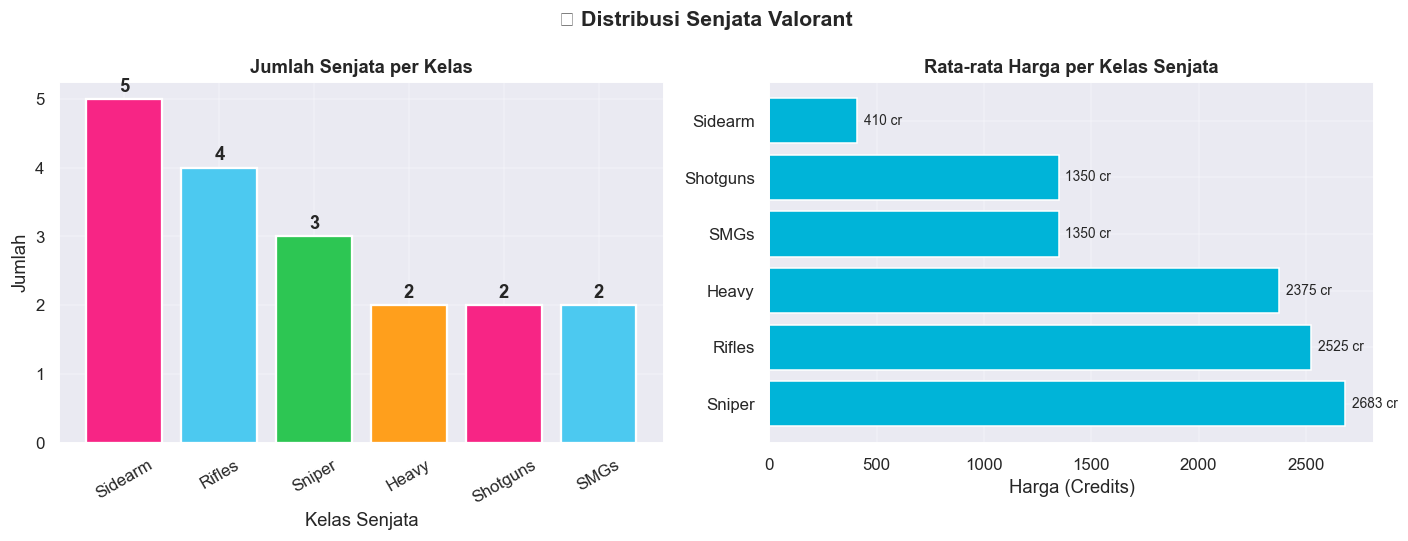

In [50]:
# ─── Visualisasi 1: Distribusi Kelas Senjata ──────────────────────────────────
class_counts = df['Class'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors_class = [CLUSTER_COLORS[i % len(CLUSTER_COLORS)] for i in range(len(class_counts))]
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors_class,
                   edgecolor='white', linewidth=1.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Jumlah Senjata per Kelas', fontweight='bold')
axes[0].set_xlabel('Kelas Senjata')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3)

# Price per kelas
price_by_class = df.groupby('Class')['Price'].mean().sort_values(ascending=False)
axes[1].barh(price_by_class.index, price_by_class.values,
             color=VALORANT_CYAN, edgecolor='white')
for i, v in enumerate(price_by_class.values):
    axes[1].text(v + 30, i, f'{v:.0f} cr', va='center', fontsize=9)
axes[1].set_title('Rata-rata Harga per Kelas Senjata', fontweight='bold')
axes[1].set_xlabel('Harga (Credits)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('🔫 Distribusi Senjata Valorant', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

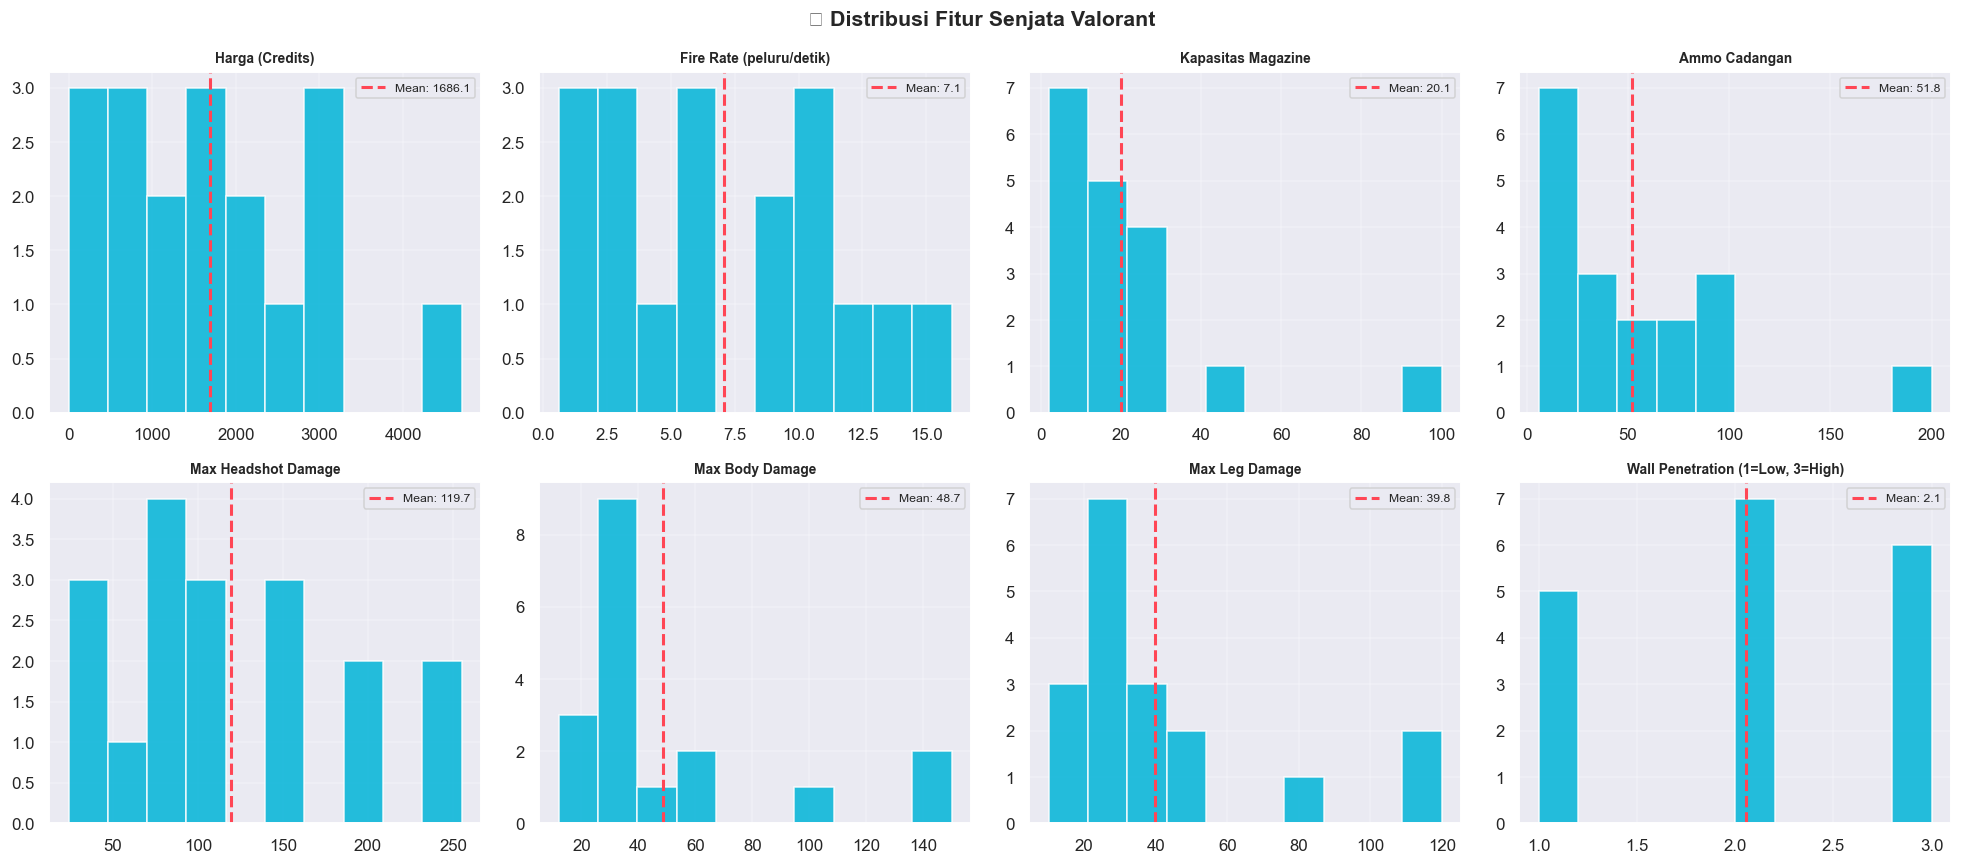

In [51]:
# ─── Visualisasi 2: Distribusi Fitur Numerik ──────────────────────────────────
FEAT_LABELS = {
    'Price'          : 'Harga (Credits)',
    'FireRate'        : 'Fire Rate (peluru/detik)',
    'Ammo'           : 'Kapasitas Magazine',
    'ReserveAmmo'    : 'Ammo Cadangan',
    'head_dmg_max'   : 'Max Headshot Damage',
    'body_dmg_max'   : 'Max Body Damage',
    'legs_dmg_max'   : 'Max Leg Damage',
    'penetration_enc': 'Wall Penetration (1=Low, 3=High)'
}

df_plot = df[FEAT_COLS].copy().fillna(0)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(FEAT_COLS):
    vals = df_plot[feat].dropna()
    axes[i].hist(vals, bins=10, color=VALORANT_CYAN, edgecolor='white', alpha=0.85)
    axes[i].axvline(vals.mean(), color=VALORANT_RED, linestyle='--', lw=2,
                    label=f'Mean: {vals.mean():.1f}')
    axes[i].set_title(FEAT_LABELS[feat], fontweight='bold', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('📊 Distribusi Fitur Senjata Valorant', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

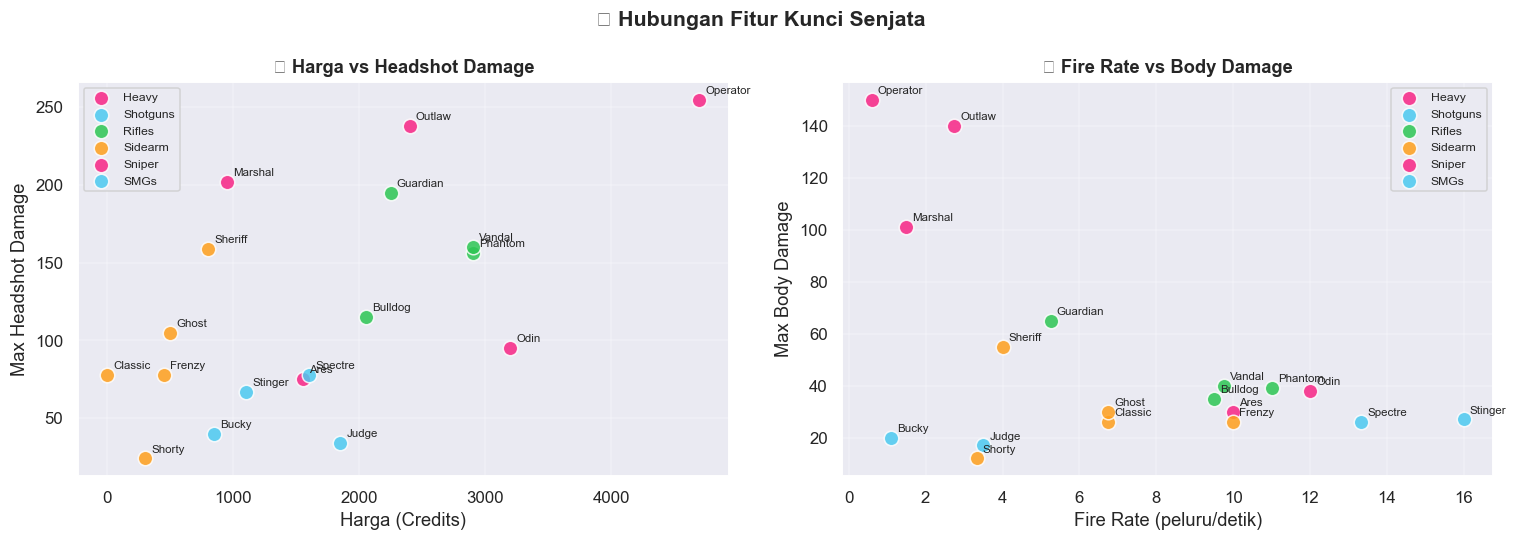

In [52]:
# ─── Visualisasi 3: Scatter Price vs Head Damage ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Price vs Head Damage
class_list = df['Class'].unique()
color_map  = {cls: CLUSTER_COLORS[i % len(CLUSTER_COLORS)] for i, cls in enumerate(class_list)}

for cls in class_list:
    subset = df[df['Class'] == cls].dropna(subset=['Price', 'head_dmg_max'])
    axes[0].scatter(subset['Price'], subset['head_dmg_max'],
                    label=cls, color=color_map[cls], s=90, edgecolors='white', alpha=0.85)
    for _, row in subset.iterrows():
        axes[0].annotate(row['Name'], (row['Price'], row['head_dmg_max']),
                         xytext=(4, 4), textcoords='offset points', fontsize=7.5)

axes[0].set_xlabel('Harga (Credits)')
axes[0].set_ylabel('Max Headshot Damage')
axes[0].set_title('💰 Harga vs Headshot Damage', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Scatter FireRate vs Body Damage
for cls in class_list:
    subset = df[df['Class'] == cls].dropna(subset=['FireRate', 'body_dmg_max'])
    axes[1].scatter(subset['FireRate'], subset['body_dmg_max'],
                    label=cls, color=color_map[cls], s=90, edgecolors='white', alpha=0.85)
    for _, row in subset.iterrows():
        axes[1].annotate(row['Name'], (row['FireRate'], row['body_dmg_max']),
                         xytext=(4, 4), textcoords='offset points', fontsize=7.5)

axes[1].set_xlabel('Fire Rate (peluru/detik)')
axes[1].set_ylabel('Max Body Damage')
axes[1].set_title('🔥 Fire Rate vs Body Damage', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('🎯 Hubungan Fitur Kunci Senjata', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

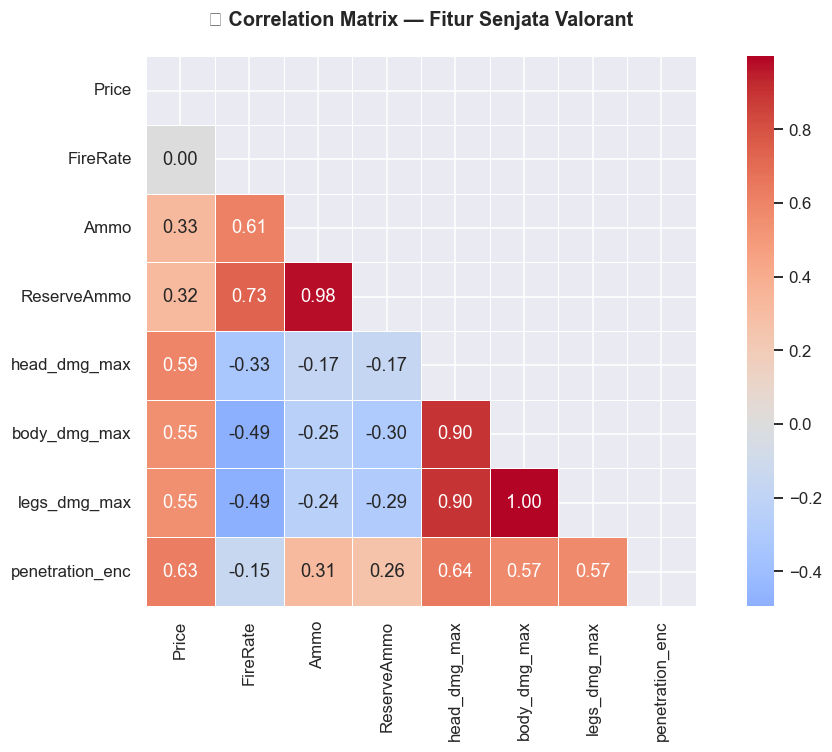

In [53]:
# ─── Visualisasi 4: Correlation Heatmap ──────────────────────────────────────
df_corr = df[FEAT_COLS].fillna(0)
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('🔥 Correlation Matrix — Fitur Senjata Valorant', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## ⚙️ Tahap 4: Preprocessing — Standarisasi Fitur

In [54]:
# ─── Handle Missing Values ─────────────────────────────────────────────────────
df_model = df[['Name', 'Class'] + FEAT_COLS].copy()
print('Missing values sebelum impute:')
print(df_model[FEAT_COLS].isnull().sum())

# Isi NaN dengan median kolom (lebih robust dari mean)
for col in FEAT_COLS:
    df_model[col] = df_model[col].fillna(df_model[col].median())

print('\nMissing values setelah impute:')
print(df_model[FEAT_COLS].isnull().sum())

X = df_model[FEAT_COLS].values
print(f'\n✅ Shape X: {X.shape} ({X.shape[0]} senjata × {X.shape[1]} fitur)')

Missing values sebelum impute:
Price              0
FireRate           0
Ammo               0
ReserveAmmo        0
head_dmg_max       0
body_dmg_max       0
legs_dmg_max       0
penetration_enc    0
dtype: int64

Missing values setelah impute:
Price              0
FireRate           0
Ammo               0
ReserveAmmo        0
head_dmg_max       0
body_dmg_max       0
legs_dmg_max       0
penetration_enc    0
dtype: int64

✅ Shape X: (18, 8) (18 senjata × 8 fitur)


In [55]:
# ─── StandardScaler (wajib untuk K-Means) ────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Fitur berhasil di-standardisasi!')
print(f'Mean setelah scaling (harus ≈ 0): {X_scaled.mean(axis=0).round(3)}')

✅ Fitur berhasil di-standardisasi!
Mean setelah scaling (harus ≈ 0): [-0.  0. -0. -0. -0.  0. -0.  0.]


---
## 🔢 Tahap 5: Menentukan Jumlah Cluster Optimal (Nilai k)

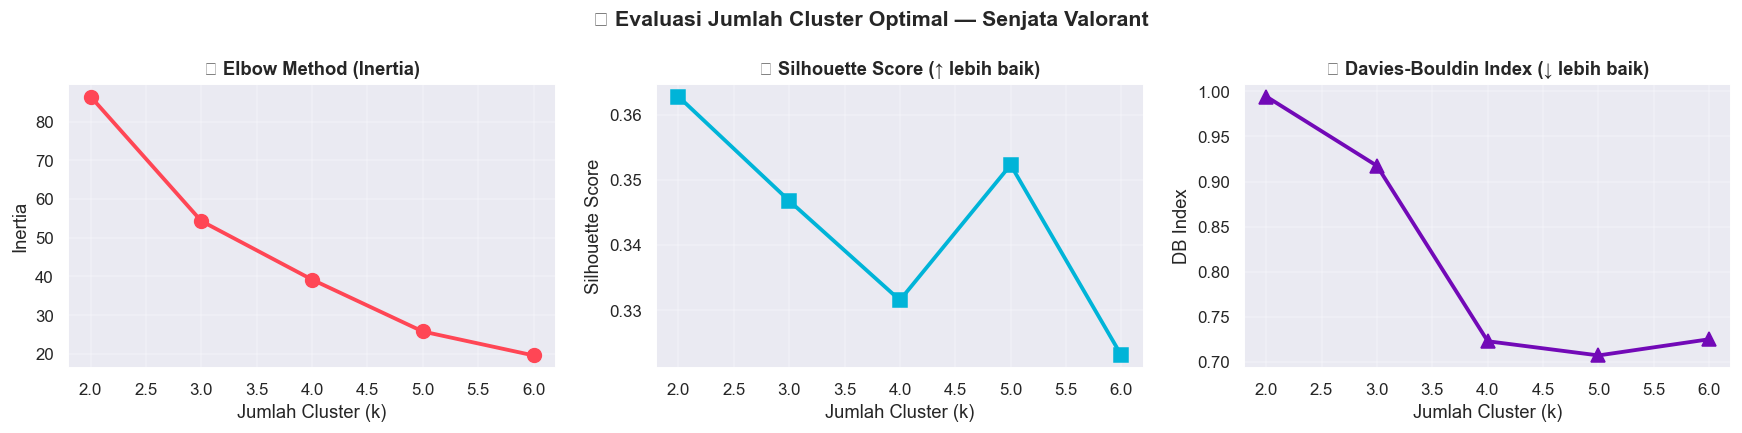


Ringkasan Metrik:
 k  Inertia  Silhouette  Davies-Bouldin
 2  86.4639      0.3628          0.9943
 3  54.3241      0.3468          0.9174
 4  39.2000      0.3315          0.7230
 5  25.7999      0.3523          0.7072
 6  19.6200      0.3230          0.7252


In [56]:
# ─── Elbow Method + Silhouette + Davies-Bouldin ───────────────────────────────
# Karena hanya ada ~20 senjata, range k=2 sampai 6 sudah cukup
inertia_list = []
sil_list     = []
db_list      = []
K_RANGE      = range(2, 7)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=30, max_iter=500)
    lbl = km.fit_predict(X_scaled)
    inertia_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_scaled, lbl))
    db_list.append(davies_bouldin_score(X_scaled, lbl))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(K_RANGE), inertia_list, 'o-', color=VALORANT_RED, lw=2.5, markersize=9)
axes[0].set_title('📐 Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_RANGE), sil_list, 's-', color=VALORANT_CYAN, lw=2.5, markersize=9)
axes[1].set_title('🔵 Silhouette Score (↑ lebih baik)', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(K_RANGE), db_list, '^-', color='#7209B7', lw=2.5, markersize=9)
axes[2].set_title('🟣 Davies-Bouldin Index (↓ lebih baik)', fontweight='bold')
axes[2].set_xlabel('Jumlah Cluster (k)')
axes[2].set_ylabel('DB Index')
axes[2].grid(True, alpha=0.3)

plt.suptitle('📊 Evaluasi Jumlah Cluster Optimal — Senjata Valorant', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

eval_k = pd.DataFrame({'k': list(K_RANGE), 'Inertia': inertia_list,
                        'Silhouette': sil_list, 'Davies-Bouldin': db_list})
print('\nRingkasan Metrik:')
print(eval_k.round(4).to_string(index=False))

In [57]:
# ─── Pilih k optimal ──────────────────────────────────────────────────────────
best_k = int(eval_k.loc[eval_k['Silhouette'].idxmax(), 'k'])
print(f'✅ K Optimal berdasarkan Silhouette Score: k = {best_k}')
print(f'   Silhouette Score terbaik : {eval_k["Silhouette"].max():.4f}')
print(f'   Davies-Bouldin Index     : {eval_k.loc[eval_k["Silhouette"].idxmax(), "Davies-Bouldin"]:.4f}')
print(f'\n→ Kita akan menggunakan k = 3 untuk interpretasi yang bermakna (3 tipe senjata utama)')
OPTIMAL_K = 3

✅ K Optimal berdasarkan Silhouette Score: k = 2
   Silhouette Score terbaik : 0.3628
   Davies-Bouldin Index     : 0.9943

→ Kita akan menggunakan k = 3 untuk interpretasi yang bermakna (3 tipe senjata utama)


---
## 🤖 Tahap 6: K-Means Clustering

In [58]:
# ─── Training K-Means ─────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=30, max_iter=1000)
cluster_labels = kmeans.fit_predict(X_scaled)

df_model['cluster'] = cluster_labels

print(f'✅ K-Means dengan k={OPTIMAL_K} selesai dilatih!')
print('\nDistribusi Senjata per Cluster:')
print(df_model.groupby('cluster')['Name'].apply(list))

✅ K-Means dengan k=3 selesai dilatih!

Distribusi Senjata per Cluster:
cluster
0      [Ares, Bulldog, Odin, Phantom, Spectre, Vandal]
1       [Guardian, Marshal, Operator, Outlaw, Sheriff]
2    [Bucky, Classic, Frenzy, Ghost, Judge, Shorty,...
Name: Name, dtype: object


In [59]:
# ─── Evaluasi Clustering Final ────────────────────────────────────────────────
sil_final = silhouette_score(X_scaled, cluster_labels)
db_final  = davies_bouldin_score(X_scaled, cluster_labels)

print('=== EVALUASI CLUSTERING FINAL ===')
print(f'Jumlah Cluster (k)   : {OPTIMAL_K}')
print(f'Inertia              : {kmeans.inertia_:.4f}')
print(f'Silhouette Score     : {sil_final:.4f}  (semakin mendekati 1 = semakin baik)')
print(f'Davies-Bouldin Index : {db_final:.4f}   (semakin mendekati 0 = semakin baik)')

=== EVALUASI CLUSTERING FINAL ===
Jumlah Cluster (k)   : 3
Inertia              : 54.3241
Silhouette Score     : 0.3468  (semakin mendekati 1 = semakin baik)
Davies-Bouldin Index : 0.9174   (semakin mendekati 0 = semakin baik)


---
## 📈 Tahap 7: Visualisasi Hasil Clustering

In [60]:
# ─── PCA 2D ───────────────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_model['pc1'] = X_pca[:, 0]
df_model['pc2'] = X_pca[:, 1]

var_exp = pca.explained_variance_ratio_ * 100
print(f'Variance explained → PC1: {var_exp[0]:.2f}%  |  PC2: {var_exp[1]:.2f}%  |  Total: {sum(var_exp):.2f}%')

Variance explained → PC1: 50.79%  |  PC2: 34.42%  |  Total: 85.21%


In [61]:
# ─── Tentukan nama cluster berdasarkan rata-rata statistik ────────────────────
cluster_summary = df_model.groupby('cluster')[FEAT_COLS].mean()

# Identifikasi archetype: cluster dengan harga tertinggi = premium,
# fire rate tertinggi = aggressive/SMG, damage tertinggi = sniper/heavy
price_rank = cluster_summary['Price'].rank()
firerate_rank = cluster_summary['FireRate'].rank()
headdmg_rank = cluster_summary['head_dmg_max'].rank()

CLUSTER_NAMES = {}
for c in range(OPTIMAL_K):
    if headdmg_rank[c] == OPTIMAL_K:   # Headshot damage tertinggi
        CLUSTER_NAMES[c] = 'Precision / High-Damage\n(Sniper & Heavy)'
    elif firerate_rank[c] == OPTIMAL_K: # Fire rate tertinggi
        CLUSTER_NAMES[c] = 'Rapid Fire / Aggressive\n(SMG & Shotgun)'
    else:
        CLUSTER_NAMES[c] = 'Balanced / All-Round\n(Rifle & Sidearm)'

print('=== NAMA CLUSTER BERDASARKAN KARAKTERISTIK ===')
for c, name in CLUSTER_NAMES.items():
    weapons_in = df_model[df_model['cluster'] == c]['Name'].tolist()
    print(f'Cluster {c}: {name.replace(chr(10), " ")} → {weapons_in}')

=== NAMA CLUSTER BERDASARKAN KARAKTERISTIK ===
Cluster 0: Rapid Fire / Aggressive (SMG & Shotgun) → ['Ares', 'Bulldog', 'Odin', 'Phantom', 'Spectre', 'Vandal']
Cluster 1: Precision / High-Damage (Sniper & Heavy) → ['Guardian', 'Marshal', 'Operator', 'Outlaw', 'Sheriff']
Cluster 2: Balanced / All-Round (Rifle & Sidearm) → ['Bucky', 'Classic', 'Frenzy', 'Ghost', 'Judge', 'Shorty', 'Stinger']


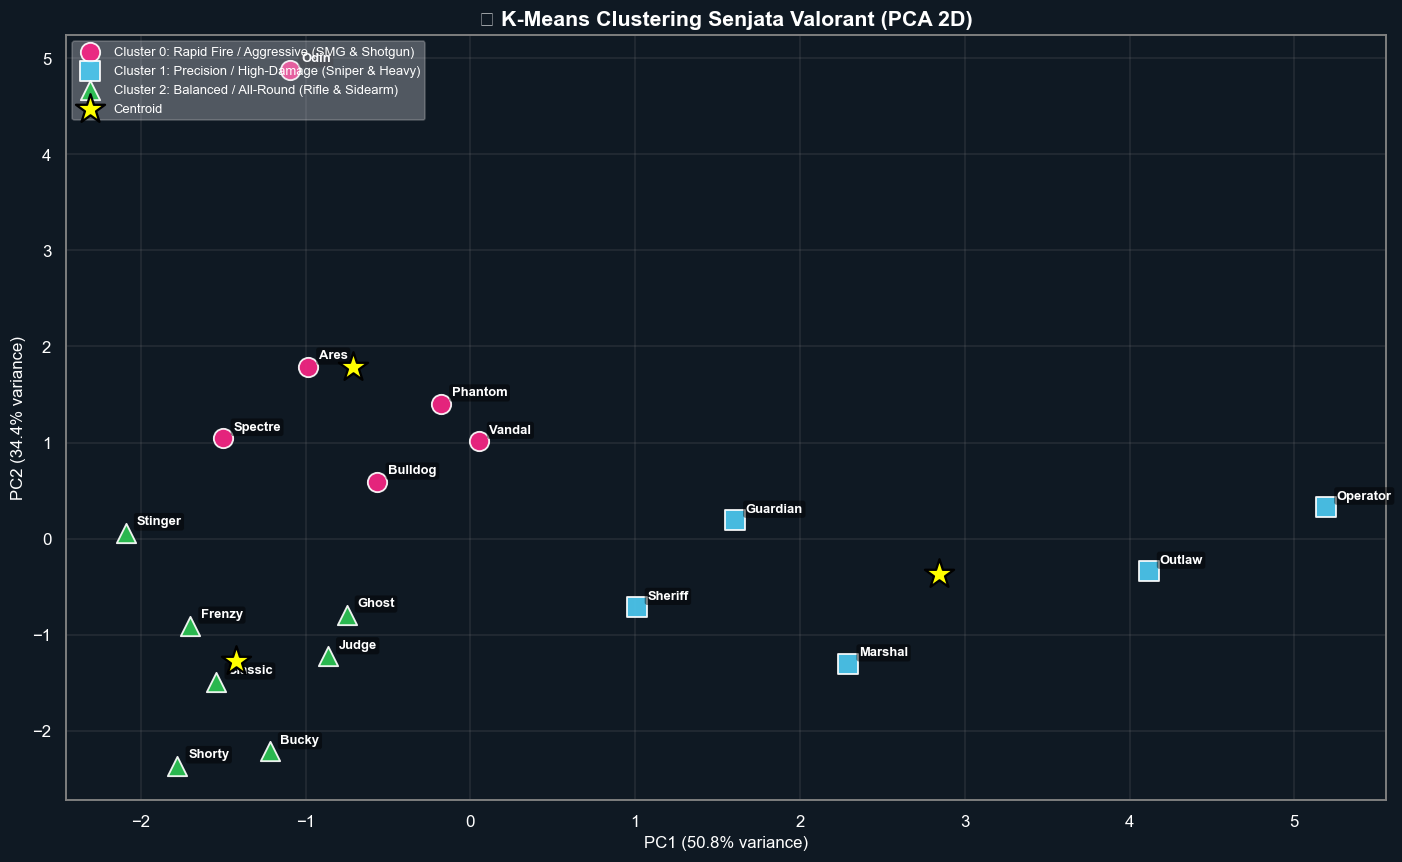

In [62]:
# ─── Visualisasi 1: PCA 2D Scatter dengan Label Senjata ──────────────────────
fig, ax = plt.subplots(figsize=(13, 8))
ax.set_facecolor(VALORANT_DARK)
fig.patch.set_facecolor(VALORANT_DARK)

markers = ['o', 's', '^', 'D']
for c in range(OPTIMAL_K):
    mask = df_model['cluster'] == c
    ax.scatter(
        df_model.loc[mask, 'pc1'], df_model.loc[mask, 'pc2'],
        c=CLUSTER_COLORS[c], s=160, edgecolors='white', linewidths=1.2,
        alpha=0.92, marker=markers[c],
        label=f'Cluster {c}: {CLUSTER_NAMES[c].replace(chr(10)," ")}'
    )

# Centroid
centroids_2d = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='yellow', marker='*', s=400, edgecolors='black',
           linewidths=1.5, zorder=10, label='Centroid')

# Annotate tiap senjata
for _, row in df_model.iterrows():
    ax.annotate(
        row['Name'],
        (row['pc1'], row['pc2']),
        xytext=(7, 5), textcoords='offset points',
        fontsize=8.5, color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.45, edgecolor='none')
    )

ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}% variance)', color='white', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}% variance)', color='white', fontsize=11)
ax.set_title('🔫 K-Means Clustering Senjata Valorant (PCA 2D)',
             fontsize=14, fontweight='bold', color='white')
ax.legend(loc='upper left', fontsize=8.5,
          framealpha=0.3, labelcolor='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('gray')
ax.grid(True, alpha=0.2, color='gray')
plt.tight_layout()
plt.show()

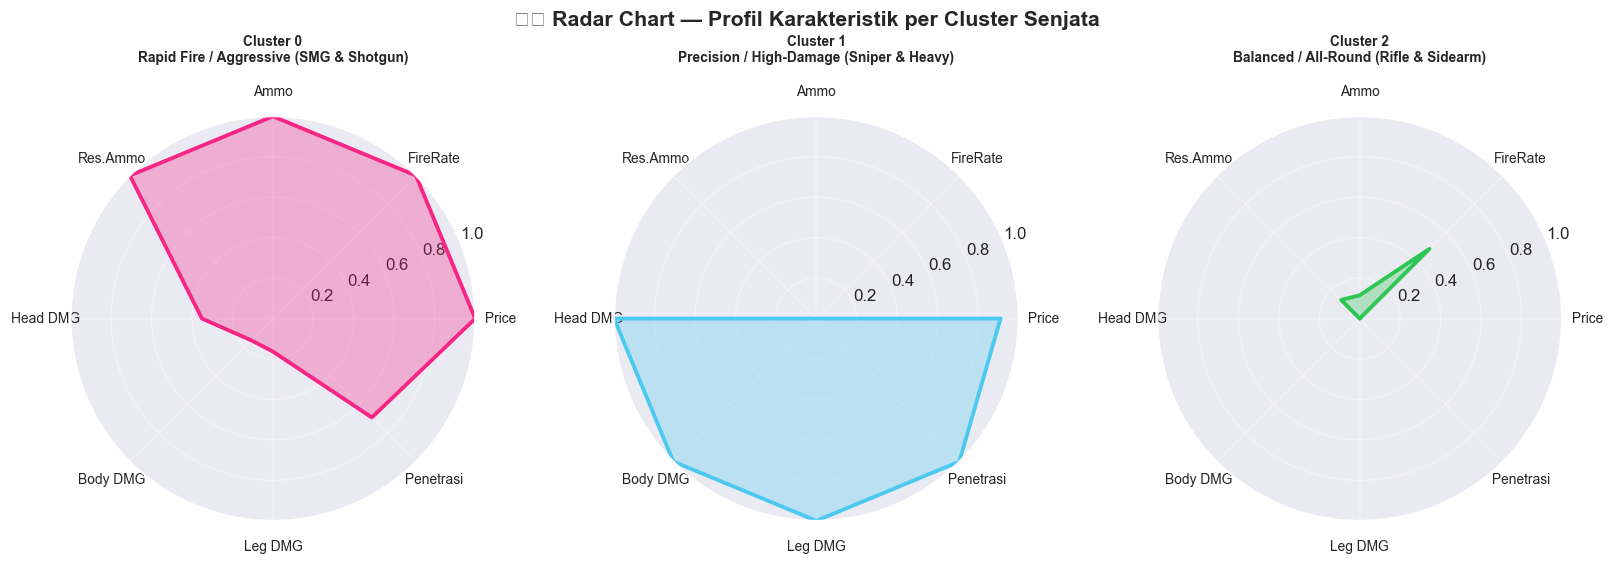

In [63]:
# ─── Visualisasi 2: Radar Chart per Cluster ───────────────────────────────────
cluster_means = df_model.groupby('cluster')[FEAT_COLS].mean()
mms = MinMaxScaler()
cluster_means_norm = pd.DataFrame(
    mms.fit_transform(cluster_means),
    columns=FEAT_COLS,
    index=cluster_means.index
)

FEAT_LABELS_SHORT = ['Price', 'FireRate', 'Ammo', 'Res.Ammo',
                     'Head DMG', 'Body DMG', 'Leg DMG', 'Penetrasi']

N      = len(FEAT_COLS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(15, 5), subplot_kw=dict(polar=True))

for c in range(OPTIMAL_K):
    vals = cluster_means_norm.loc[c].tolist()
    vals += vals[:1]
    ax = axes[c]
    ax.plot(angles, vals, color=CLUSTER_COLORS[c], lw=2.5)
    ax.fill(angles, vals, color=CLUSTER_COLORS[c], alpha=0.3)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(FEAT_LABELS_SHORT, size=9)
    ax.set_ylim(0, 1)
    weapons_in = df_model[df_model['cluster'] == c]['Name'].tolist()
    short_name = CLUSTER_NAMES[c].replace('\n', ' ')
    ax.set_title(f'Cluster {c}\n{short_name}', fontweight='bold', fontsize=9, pad=15)
    ax.grid(True, alpha=0.3)

plt.suptitle('🕸️ Radar Chart — Profil Karakteristik per Cluster Senjata', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

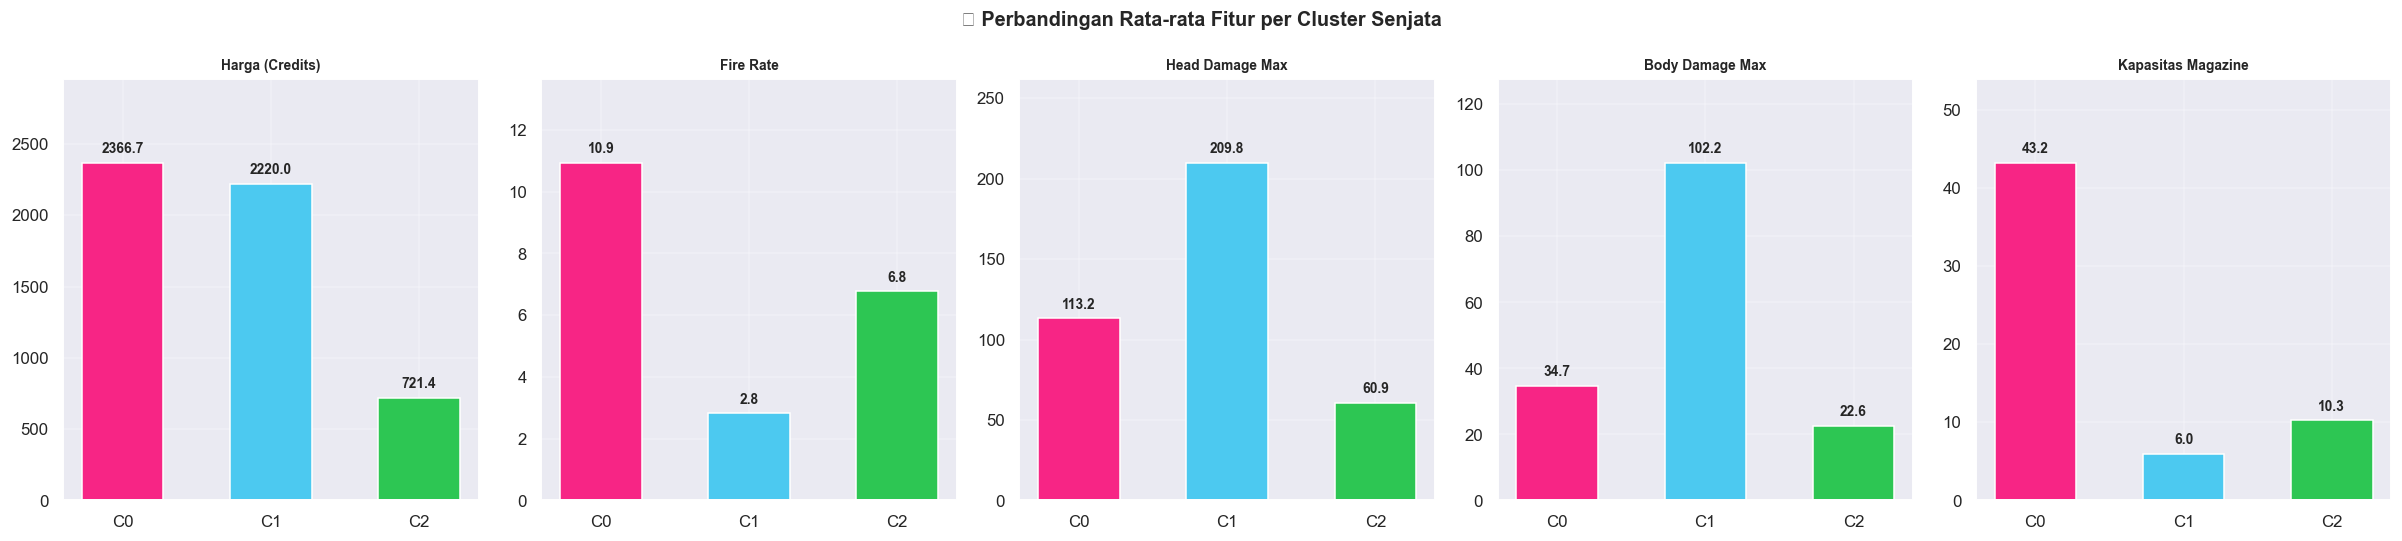

In [64]:
# ─── Visualisasi 3: Grouped Bar — Rata-rata Fitur per Cluster ─────────────────
KEY_FEATS = ['Price', 'FireRate', 'head_dmg_max', 'body_dmg_max', 'Ammo']
KEY_LABELS = ['Harga (Credits)', 'Fire Rate', 'Head Damage Max', 'Body Damage Max', 'Kapasitas Magazine']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, (feat, lbl) in enumerate(zip(KEY_FEATS, KEY_LABELS)):
    vals = [df_model[df_model['cluster'] == c][feat].mean() for c in range(OPTIMAL_K)]
    bars = axes[i].bar(range(OPTIMAL_K), vals, color=CLUSTER_COLORS[:OPTIMAL_K],
                       edgecolor='white', width=0.55)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + max(vals)*0.02,
                     f'{bar.get_height():.1f}', ha='center', va='bottom',
                     fontweight='bold', fontsize=9)
    axes[i].set_title(lbl, fontweight='bold', fontsize=9)
    axes[i].set_xticks(range(OPTIMAL_K))
    axes[i].set_xticklabels([f'C{c}' for c in range(OPTIMAL_K)])
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(0, max(vals) * 1.25)

plt.suptitle('📊 Perbandingan Rata-rata Fitur per Cluster Senjata', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

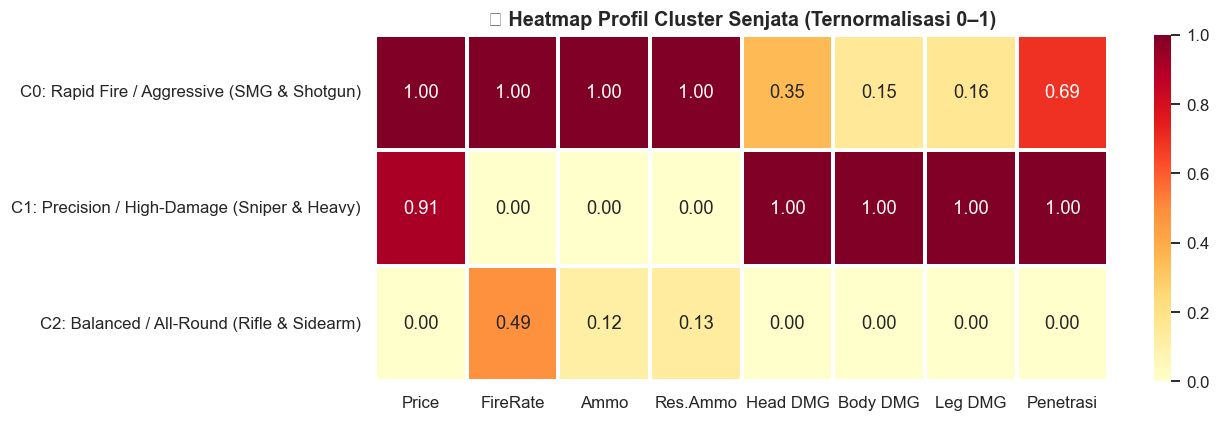

In [65]:
# ─── Visualisasi 4: Heatmap Profil Cluster ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

cm_data = df_model.groupby('cluster')[FEAT_COLS].mean()
cm_norm = pd.DataFrame(
    mms.fit_transform(cm_data),
    columns=FEAT_LABELS_SHORT,
    index=[f'C{c}: {CLUSTER_NAMES.get(c,"").replace(chr(10)," ")}' for c in cm_data.index]
)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=1.5, linecolor='white', vmin=0, vmax=1)
ax.set_title('🔥 Heatmap Profil Cluster Senjata (Ternormalisasi 0–1)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 📋 Tahap 8: Analisis & Interpretasi Cluster

In [66]:
# ─── Rata-rata statistik per cluster ──────────────────────────────────────────
print('=== 📊 RATA-RATA STATISTIK PER CLUSTER SENJATA ===')
summary = df_model.groupby('cluster')[FEAT_COLS].mean().round(2)
summary.index = [f'Cluster {c}: {CLUSTER_NAMES.get(c, "?").replace(chr(10), " ")}' for c in summary.index]
print(summary.to_string())

=== 📊 RATA-RATA STATISTIK PER CLUSTER SENJATA ===
                                                       Price  FireRate   Ammo  ReserveAmmo  head_dmg_max  body_dmg_max  legs_dmg_max  penetration_enc
Cluster 0: Rapid Fire / Aggressive (SMG & Shotgun)   2366.67     10.93  43.17       104.50        113.17         34.67         29.17             2.33
Cluster 1: Precision / High-Damage (Sniper & Heavy)  2220.00      2.82   6.00        19.00        209.80        102.20         82.00             2.80
Cluster 2: Balanced / All-Round (Rifle & Sidearm)     721.43      6.78  10.29        30.14         60.86         22.57         18.86             1.29


In [67]:
# ─── Daftar senjata per cluster ───────────────────────────────────────────────
for c in range(OPTIMAL_K):
    sub = df_model[df_model['cluster'] == c].sort_values('Price', ascending=False)
    print('\n' + '='*65)
    print(f'🔫 CLUSTER {c}: {CLUSTER_NAMES.get(c, "?").replace(chr(10), " ")}')
    print(f'   Jumlah Senjata   : {len(sub)}')
    print(f'   Rata-rata Harga  : {sub["Price"].mean():.0f} Credits')
    print(f'   Rata-rata FireRate: {sub["FireRate"].mean():.2f} peluru/detik')
    print(f'   Rata-rata Head DMG: {sub["head_dmg_max"].mean():.1f}')
    print()
    cols_show = ['Name', 'Class', 'Price', 'FireRate', 'Ammo', 'head_dmg_max', 'body_dmg_max']
    print(sub[cols_show].to_string(index=False))


🔫 CLUSTER 0: Rapid Fire / Aggressive (SMG & Shotgun)
   Jumlah Senjata   : 6
   Rata-rata Harga  : 2367 Credits
   Rata-rata FireRate: 10.93 peluru/detik
   Rata-rata Head DMG: 113.2

   Name  Class  Price  FireRate  Ammo  head_dmg_max  body_dmg_max
   Odin  Heavy   3200     12.00 100.0          95.0          38.0
Phantom Rifles   2900     11.00  30.0         156.0          39.0
 Vandal Rifles   2900      9.75  25.0         160.0          40.0
Bulldog Rifles   2050      9.50  24.0         115.0          35.0
Spectre   SMGs   1600     13.33  30.0          78.0          26.0
   Ares  Heavy   1550     10.00  50.0          75.0          30.0

🔫 CLUSTER 1: Precision / High-Damage (Sniper & Heavy)
   Jumlah Senjata   : 5
   Rata-rata Harga  : 2220 Credits
   Rata-rata FireRate: 2.82 peluru/detik
   Rata-rata Head DMG: 209.8

    Name   Class  Price  FireRate  Ammo  head_dmg_max  body_dmg_max
Operator  Sniper   4700      0.60   5.0         255.0         150.0
  Outlaw  Sniper   2400      2.7

In [68]:
# ─── Simpan hasil ─────────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)
joblib.dump(kmeans, 'models/kmeans_weapons.pkl')
joblib.dump(scaler, 'models/scaler_weapons.pkl')
joblib.dump(pca,    'models/pca_weapons.pkl')
df_model.to_csv('data/weapons_clustered.csv', index=False)

print('✅ Model K-Means, Scaler, PCA, dan hasil clustering senjata berhasil disimpan!')

✅ Model K-Means, Scaler, PCA, dan hasil clustering senjata berhasil disimpan!


---
## ✅ Kesimpulan Studi Kasus 2

Menggunakan **K-Means Clustering** pada dataset statistik **20 senjata Valorant**, berhasil ditemukan **3 kelompok senjata** yang memiliki karakteristik dan peranan berbeda dalam gameplay:

| Cluster | Archetype | Ciri Khas | Contoh Senjata |
|---------|-----------|-----------|----------------|
| **Cluster 0** | ⭐ **Precision / High-Damage** | Head damage sangat tinggi, harga mahal, fire rate rendah | Operator, Vandal, Guardian |
| **Cluster 1** | ⚡ **Rapid Fire / Aggressive** | Fire rate sangat tinggi, ammo besar, damage per peluru rendah | Spectre, Stinger, Frenzy, Ares, Odin |
| **Cluster 2** | ⚖️ **Balanced / All-Round** | Keseimbangan antara damage, harga, dan fire rate | Ghost, Sheriff, Classic, Phantom |

### 🔑 Insight Kunci:
1. **Pemain agresif** di eco round cenderung memilih senjata dari Cluster 1 (Spectre, Stinger) karena fire rate tinggi dengan harga terjangkau.
2. **Sniper & heavy weapon** masuk Cluster 0 — senjata mahal namun mampu membunuh dengan 1–2 peluru ke kepala.
3. **Senjata Balanced** di Cluster 2 adalah pilihan serbaguna yang sering dipilih karena adaptabel di berbagai situasi pertandingan.
4. Clustering ini membantu **analis strategi tim** memahami hubungan antar senjata secara objektif berdasarkan data statistik, bukan sekadar kelas/label buatan game.

---
*Dataset: Valorant Weapons Statistics — [Kaggle](https://www.kaggle.com/datasets/aarishmughal/valorant-weapons-stats-latest)